# Generate precision-recall curve on held-out test data comparing coSMicQC and PyOD ECOD

This code is derived from the `cellpainting_predicts_cardiac_fibrosis` repository.


In [1]:
import pathlib
import sys

import joblib
import pandas as pd
from joblib import load
from plotnine import (
    aes,
    element_line,
    element_text,
    geom_line,
    ggplot,
    labs,
    scale_color_manual,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from sklearn.metrics import average_precision_score, precision_recall_curve

sys.path.append("../figure_3")
from figure3_utils import get_X_y_data


In [2]:
figure_path = pathlib.Path("./figures")
# make directory if it doesn't already exist
figure_path.mkdir(exist_ok=True)


## Load in label encoder

In [3]:
# load in label encoder
le = load(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/5.machine_learning/0.train_logistic_regression/encoder_results/label_encoder_log_reg_fs_plate_4.joblib"
    )
)


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.3.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


## Load in no-QC model and dataset

In [4]:
# Load the trained model
no_QC_model = joblib.load(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/5.machine_learning/0.train_logistic_regression/models/no_QC_models/log_reg_fs_plate_4_final_downsample_no_QC.joblib"
    )
)

# Load the feature-selected QC plate 4 (ensure it includes both features and labels)
plate_4_no_QC = pd.read_parquet(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost231120090001_sc_feature_selected_no_QC.parquet"
    )
)

# Filter the test_data to only include rows where:
# - Metadata_heart_number == 7 and Metadata_treatment == "DMSO"
# - OR Metadata_heart_number == 29
healthy_heart_number = 7
failing_heart_number = 29
holdout_no_QC_data = plate_4_no_QC[
    (
        (plate_4_no_QC["Metadata_heart_number"] == healthy_heart_number)
        & (plate_4_no_QC["Metadata_treatment"] == "DMSO")
    )
    | (plate_4_no_QC["Metadata_heart_number"] == failing_heart_number)
]
print(f"Holdout no QC data shape: {holdout_no_QC_data.shape}")

# Load in X and y data from dataset
X, y = get_X_y_data(df=holdout_no_QC_data, label="Metadata_cell_type")

# Assign y classes to correct binary using label encoder results
y_binary_no_QC = le.transform(y)

# Predict probabilities for the positive class
y_probs_modelNoQC = no_QC_model.predict_proba(X)[:, 1]


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


Holdout no QC data shape: (3998, 667)


## Load in coSMicQC model and dataset

In [5]:
# Load the trained model
QC_model = joblib.load(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/5.machine_learning/0.train_logistic_regression/models/log_reg_fs_plate_4_final_downsample.joblib"
    )
)

# Load the feature-selected QC plate 4 (ensure it includes both features and labels)
plate_4_QC = pd.read_parquet(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost231120090001_sc_feature_selected.parquet"
    )
)

# Filter the test_data to only include rows where:
# - Metadata_heart_number == 7 and Metadata_treatment == "DMSO"
# - OR Metadata_heart_number == 29
holdout_QC_data = plate_4_QC[
    (
        (plate_4_QC["Metadata_heart_number"] == healthy_heart_number)
        & (plate_4_QC["Metadata_treatment"] == "DMSO")
    )
    | (plate_4_QC["Metadata_heart_number"] == failing_heart_number)
]
print(f"Holdout QC data shape: {holdout_QC_data.shape}")

# Load in X and y data from dataset
X, y = get_X_y_data(df=holdout_QC_data, label="Metadata_cell_type")

# Assign y classes to correct binary using label encoder results
y_binary_QC = le.transform(y)

# Predict probabilities for the positive class
y_probs_modelQC = QC_model.predict_proba(X)[:, 1]


Holdout QC data shape: (3008, 644)


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


## Load in ECOD model and dataset

In [6]:
# Load the trained model
ECOD_model = joblib.load(
    pathlib.Path(
        "../figure_3/models/log_reg_fs_ecod_final_downsample.joblib"
    )
)

# Load the feature-selected QC plate 4 (ensure it includes both features and labels)
plate_4_ECOD = pd.read_parquet(
    pathlib.Path(
        "../figure_3/models/idc_normalized_feature_selected.parquet"
    )
)

# Filter the test_data to only include rows where:
# - Metadata_heart_number == 7 and Metadata_treatment == "DMSO"
# - OR Metadata_heart_number == 29
holdout_ECOD_data = plate_4_ECOD[
    (
        (plate_4_ECOD["Metadata_heart_number"] == healthy_heart_number)
        & (plate_4_ECOD["Metadata_treatment"] == "DMSO")
    )
    | (plate_4_ECOD["Metadata_heart_number"] == failing_heart_number)
]
print(f"Holdout ECOD data shape: {holdout_ECOD_data.shape}")

# Load in X and y data from dataset
X, y = get_X_y_data(df=holdout_ECOD_data, label="Metadata_cell_type")

# Assign y classes to correct binary using label encoder results
y_binary_ECOD = le.transform(y)

# Predict probabilities for the positive class
y_probs_modelECOD = ECOD_model.predict_proba(X)[:, 1]


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


Holdout ECOD data shape: (2807, 720)


## Compute precision-recall curves and plot

Average precision No-QC: 0.812
Average precision QC: 0.857
Average precision ECOD: 0.875


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 11 x 7 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/precision_recall_curves_holdout.png


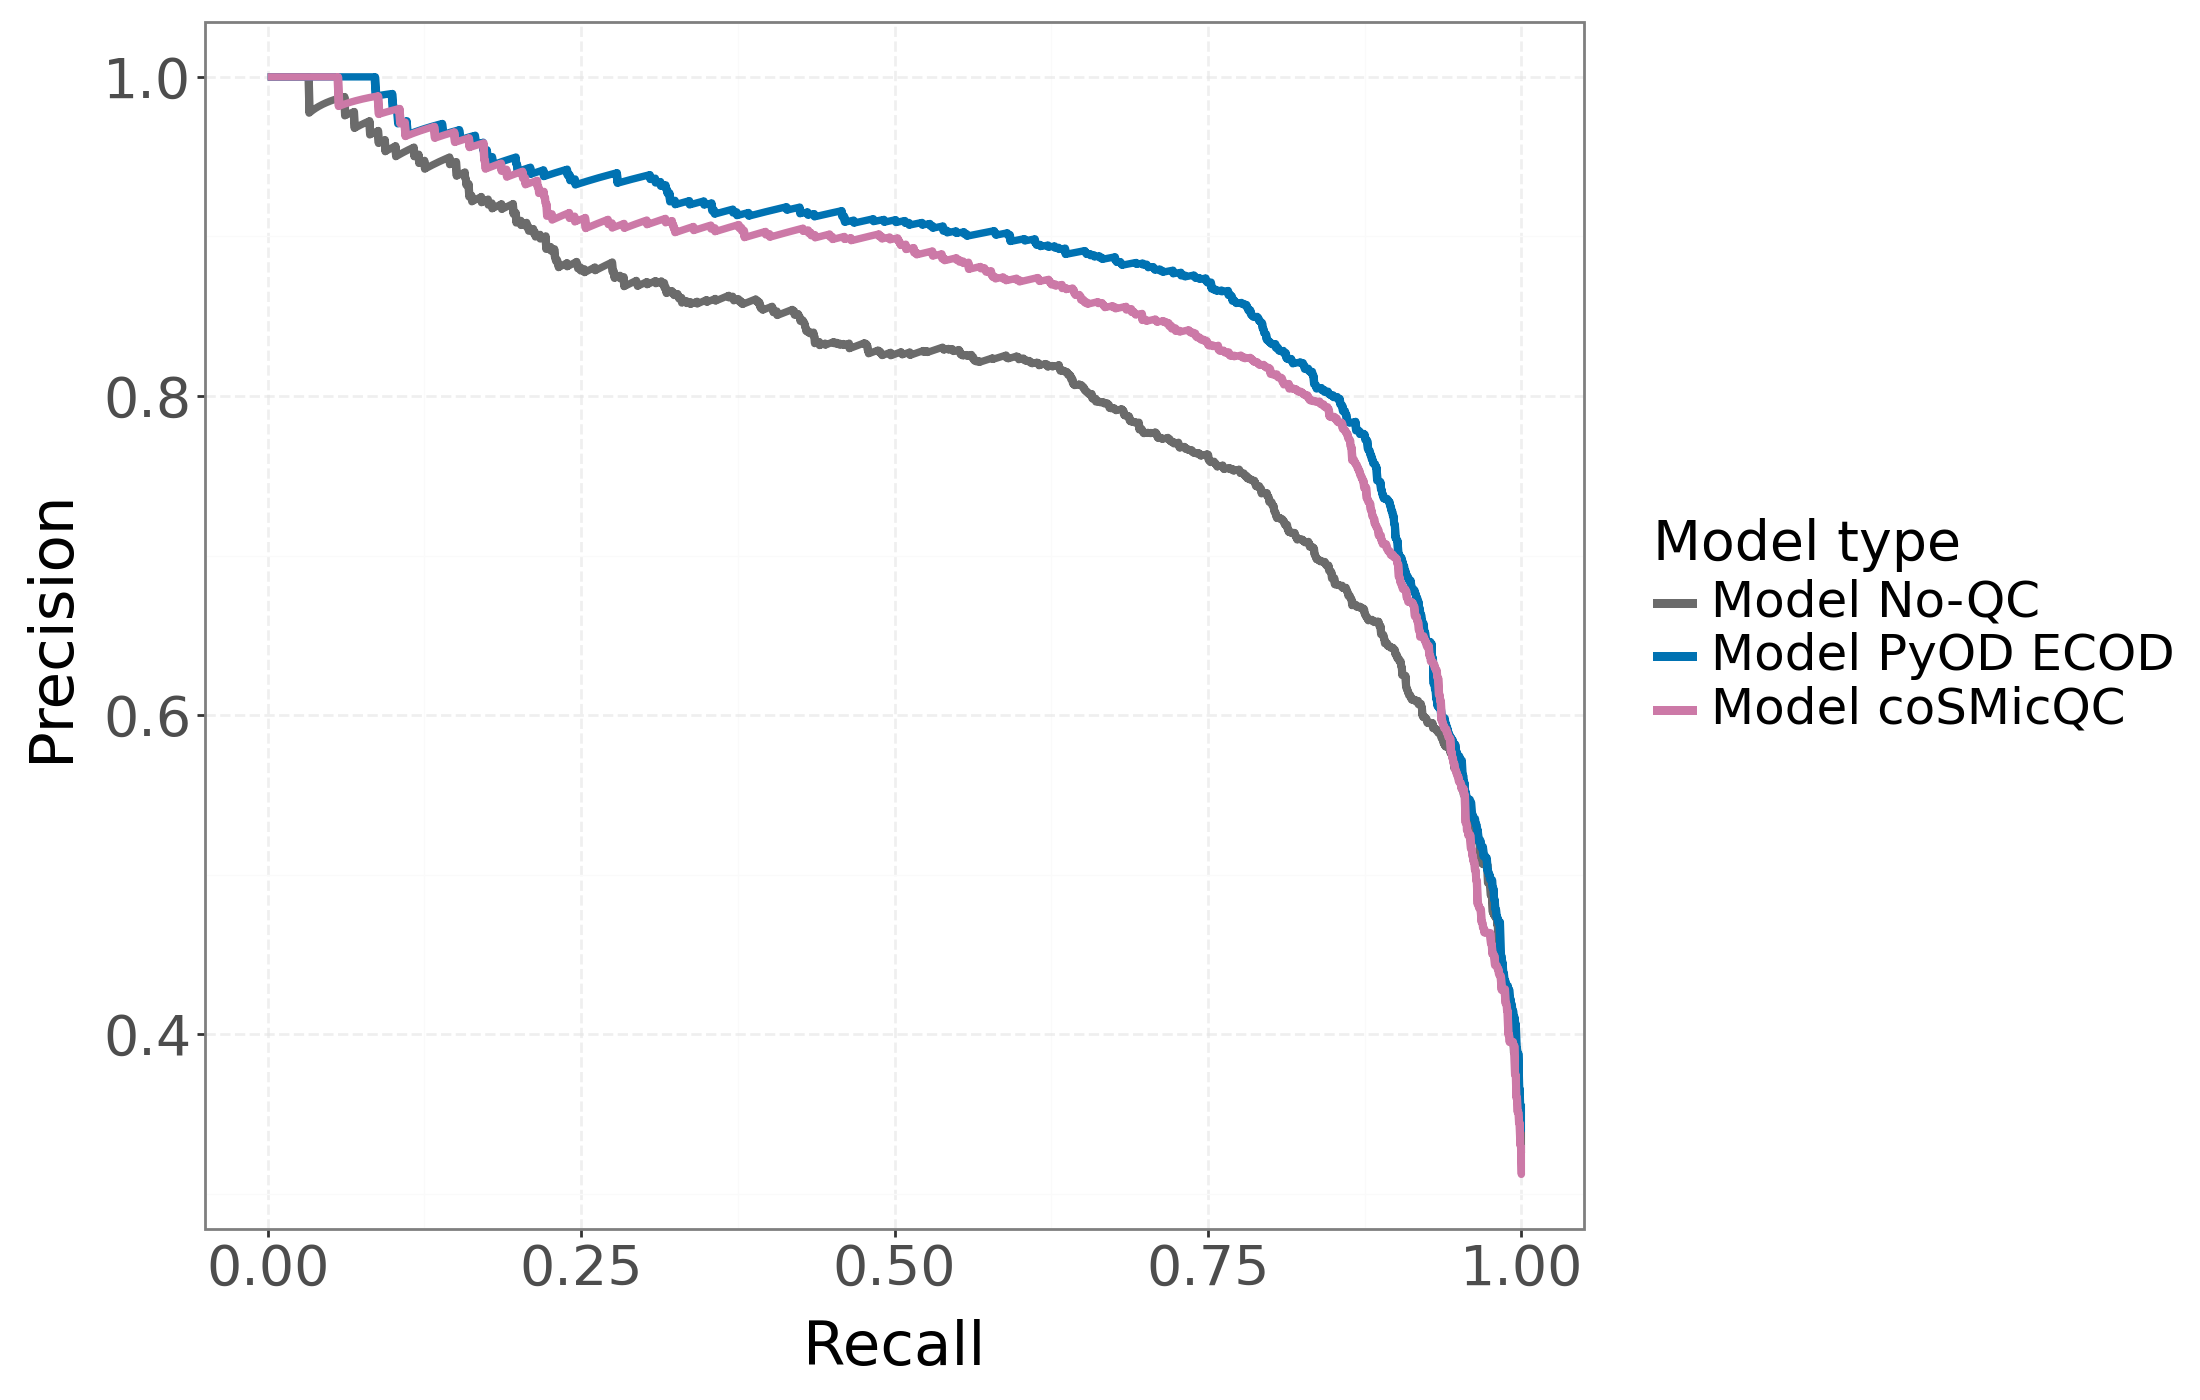

In [7]:
# Compute precision-recall curves
precision_noQC, recall_noQC, _ = precision_recall_curve(
    y_binary_no_QC, y_probs_modelNoQC
)
precision_QC, recall_QC, _ = precision_recall_curve(y_binary_QC, y_probs_modelQC)
precision_ECOD, recall_ECOD, _ = precision_recall_curve(
    y_binary_ECOD, y_probs_modelECOD
)

# Optional average precision scores
ap_noQC = average_precision_score(y_binary_no_QC, y_probs_modelNoQC)
ap_QC = average_precision_score(y_binary_QC, y_probs_modelQC)
ap_ECOD = average_precision_score(y_binary_ECOD, y_probs_modelECOD)

print(f"Average precision No-QC: {ap_noQC:.3f}")
print(f"Average precision QC: {ap_QC:.3f}")
print(f"Average precision ECOD: {ap_ECOD:.3f}")

df_noQC = pd.DataFrame(
    {"recall": recall_noQC, "precision": precision_noQC, "model": "Model No-QC"}
)
df_QC = pd.DataFrame(
    {"recall": recall_QC, "precision": precision_QC, "model": "Model coSMicQC"}
)
df_ECOD = pd.DataFrame(
    {"recall": recall_ECOD, "precision": precision_ECOD, "model": "Model PyOD ECOD"}
)

df_pr = pd.concat([df_noQC, df_QC, df_ECOD], ignore_index=True)

set_option("figure_size", (11, 7))

p = (
    ggplot(df_pr, aes(x="recall", y="precision", color="model"))
    + geom_line(size=1.5)
    + scale_color_manual(
        values={
            "Model No-QC": "#6B6B6B",
            "Model coSMicQC": "#CC79A7",
            "Model PyOD ECOD": "#0072B2",
        }
    )
    + labs(
        x="Recall",
        y="Precision",
        color="Model type",
    )
    + theme_bw()
    + theme(
        legend_position="right",
        legend_title=element_text(size=20),
        legend_text=element_text(size=18),
        axis_title=element_text(size=22),
        axis_text=element_text(size=20),
        panel_grid_major=element_line(linetype="--", alpha=0.6),
    )
)

p.save(f"{figure_path}/precision_recall_curves_holdout.png", dpi=600)
p.show()
